In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import sys; sys.path.insert(0, '..')

from catboost import CatBoostClassifier
from src.score_construct import (
    find_base_odds, find_best_pdo, compute_feature_scores, plot_score_distribution,
    sample_scorecard_report, assign_score_bands
)
from src.back_testing import (
    bin_summary, plot_roc, plot_ks, plot_classification_monthly, plot_stability_monthly
)


In [3]:
# Load model
model = CatBoostClassifier()
model.load_model('../model/model.cbm')

CatBoostClassifier(bagging_temperature=0.1015962999, class_weights=[1, 33.64792183], depth=6, eval_metric='AUC', iterations=664, l2_leaf_reg=3.256694333, learning_rate=0.09871719221, loss_function='Logloss', min_data_in_leaf=12, random_seed=42, random_strength=0.5186399506, verbose=0)

In [4]:
# Import longlist factors
longList = pd.read_csv(
    '../data/raw/longlistFactor.csv'
)

# Define features types
CAT_COLS = longList.query(
    "data_type == 'Categorical'"
)['factor'].tolist()

NUM_COLS = longList.query(
    "data_type == 'Continuous'"
)['factor'].tolist()

In [5]:
# Define categorical features
cat_cols = [c for c in model.feature_names_ if c in set(CAT_COLS)]

In [6]:
# Import data
train = pd.read_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)
test = pd.read_parquet(
    '../data/processed/test_data.parquet',
    engine = 'pyarrow'
)

# Extract month index from historical data (For use later)
month_idx = pd.concat(
    [train, test],
    axis = 0,
    ignore_index = True
)['AS_OF_DATE']

# Define features and target
X_train = train[model.feature_names_]
y_train = train['ever_default_6']
X_test = test[model.feature_names_]
y_test = test['ever_default_6']

# Data preparation before scorecard development
X_train[cat_cols] = X_train[cat_cols].replace([np.inf, -np.inf, np.nan], -1).astype(int)
X_test[cat_cols] = X_test[cat_cols].replace([np.inf, -np.inf, np.nan], -1).astype(int)

# Remove original data
del train, test

# Show table
X_test.head(5)

,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin
13927,1.086022,0.0,1.000000,0.018681,1,0.018681
13928,1.105556,0.0,1.222222,0.018681,1,0.018681
13929,1.107345,0.0,0.555556,0.018681,1,0.018681
13930,1.090395,0.0,0.500000,0.018681,1,0.018681
13931,1.090517,0.0,0.500000,0.018681,1,0.018681


In [7]:
# Find the base odds
BASE_ODDS = find_base_odds(y_train)
print(f"=== Result ===\nBase odds: {BASE_ODDS}")

=== Result ===
Base odds: 22


In [8]:
# Constant
BASE_SCORE = 600

# Find the best PDO
PDO = find_best_pdo(
    base_model = model,
    X = X_train,
    y = y_train,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)

=== Result ===
PDO: 50
Standard Deviation: 171.40
Outbound: 17.50%


In [9]:
# Compute score
# Training set
scores_train = compute_feature_scores(
    base_model = model,
    X = X_train,
    pdo = PDO,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)

# Testing set
scores_test = compute_feature_scores(
    base_model = model,
    X = X_test,
    pdo = PDO, #Remain PDO
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS #Remain base odds
)

=== Processing ===
[Score construction]
Total input: 292001
=== Processing ===
[Score construction]
Total input: 127709


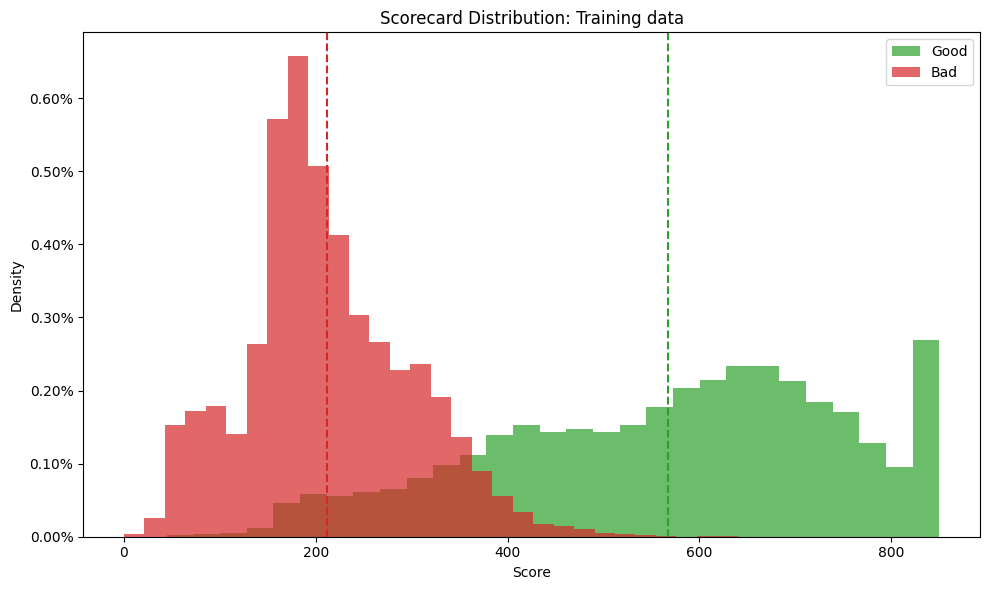

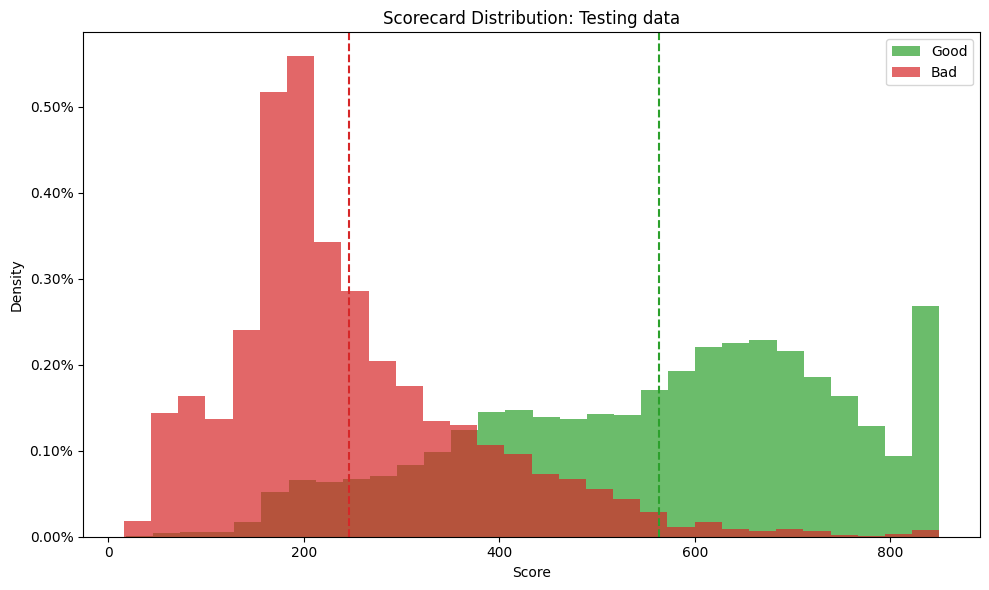

In [10]:
# Plot
# Training set
plot_score_distribution(
    scores = scores_train['score_from_model'],
    target = y_train,
    title = "Scorecard Distribution: Training data"
)

# Testing set
plot_score_distribution(
    scores = scores_test['score_from_model'],
    target = y_test,
    title = "Scorecard Distribution: Testing data"
)

=== Processing ===
[Score construction]
Total input: 419710


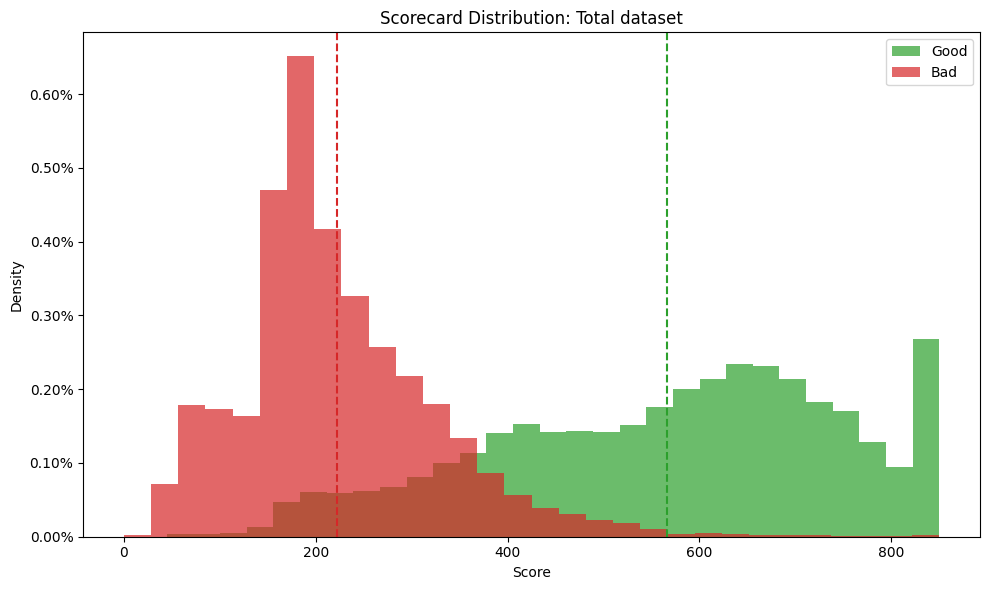

In [11]:
# Combine dataset
X_all = pd.concat(
    [X_train, X_test],
    axis = 0,
    ignore_index = True
)

y_all = pd.concat(
    [y_train, y_test],
    axis = 0,
    ignore_index = True
)

# Compute score for all dataset
scores_all = compute_feature_scores(
    base_model = model,
    X = X_all,
    pdo = PDO,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)

# Plot
plot_score_distribution(
    scores = scores_all['score_from_model'],
    target = y_all,
    title = "Scorecard Distribution: Total dataset"
)

In [12]:
# Reporting (Random)
sample_scorecard_report(
    X = X_all,
    base_model = model,
    pdo = PDO,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)



────────────────────────────────────────────────────
  Credit Score                  : 632.01
  Base Score                    : 557.71
────────────────────────────────────────────────────
                 feature  raw_value  feature_score
avg_bal_12_to_min_bal_12       1.11         -63.71
               min_pay_6    7740.00          46.55
        avg_pay_9_to_due       1.00          62.35
        max_ovd_6_to_fin       0.00          40.75
               max_del_3       0.00          26.50
        min_due_9_to_fin       0.02         -38.14
────────────────────────────────────────────────────
  Base + ΣFeature Scores       : 557.71 + 74.30
────────────────────────────────────────────────────


In [13]:
# Create new sample
# ==================================#
# 1. 'avg_bal_12_to_min_bal_12' = 2 #
# 2. 'min_pay_6' = 7000             #
# 3. 'avg_pay_9_to_due' = 1         #
# 4. 'max_ovd_6_to_fin' = 0.5       #
# 5. 'max_del_3' = 1                #
# 6. 'min_due_9_to_fin' = 0.03      #
# ==================================#
new_values = [2, 7000, 1, 0.5, 1, 0.03]
X_new = pd.DataFrame(
    [
        dict(zip(X_all.columns, new_values))
    ]
)

# Reporting (New sample)
sample_scorecard_report(
    X = X_new,
    base_model = model,
    pdo = PDO,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)


────────────────────────────────────────────────────
  Credit Score                  : 454.31
  Base Score                    : 557.71
────────────────────────────────────────────────────
                 feature  raw_value  feature_score
avg_bal_12_to_min_bal_12       2.00          50.82
               min_pay_6    7000.00          -8.31
        avg_pay_9_to_due       1.00          95.37
        max_ovd_6_to_fin       0.50        -186.57
               max_del_3       1.00         -23.91
        min_due_9_to_fin       0.03         -30.80
────────────────────────────────────────────────────
  Base + ΣFeature Scores       : 557.71 + -103.40
────────────────────────────────────────────────────


In [14]:
# Using total dataset onward
# Score bands process
score_bands = assign_score_bands(
    scores = scores_all['score_from_model'],
    n_bins = 8,
    method = 'equal'
)

In [15]:
# Summary table
score_table = bin_summary(
    scores = scores_all['score_from_model'],
    bin_labels = score_bands,
    y_true = y_all
)

# Show table
score_table

,bin,n,pct,min,max,mean,bad,odr,good,cum_bad,cum_good,roc,ks
0,B8,2927,0.01,0.0,106.0,75.67,1956,0.668261,971.0,0.109968,0.002416,0.000133,0.107552
1,B7,22078,0.05,107.0,212.0,176.56,7785,0.352613,14293.0,0.547647,0.037977,0.011693,0.509670
2,B6,33684,0.08,213.0,318.0,267.35,5264,0.156276,28420.0,0.843594,0.108687,0.049187,0.734906
3,B5,55346,0.13,319.0,425.0,376.88,2062,0.037257,53284.0,0.959521,0.241260,0.119522,0.718261
4,B4,61518,0.15,426.0,531.0,478.70,522,0.008485,60996.0,0.988868,0.393021,0.147844,0.595848
5,B3,82974,0.20,532.0,637.0,588.24,130,0.001567,82844.0,0.996177,0.599140,0.204578,0.397037
6,B2,91125,0.22,638.0,743.0,687.83,48,0.000527,91077.0,0.998876,0.825743,0.226043,0.173133
7,B1,70058,0.17,744.0,850.0,807.06,20,0.000285,70038.0,1.000000,1.000000,0.174159,0.000000


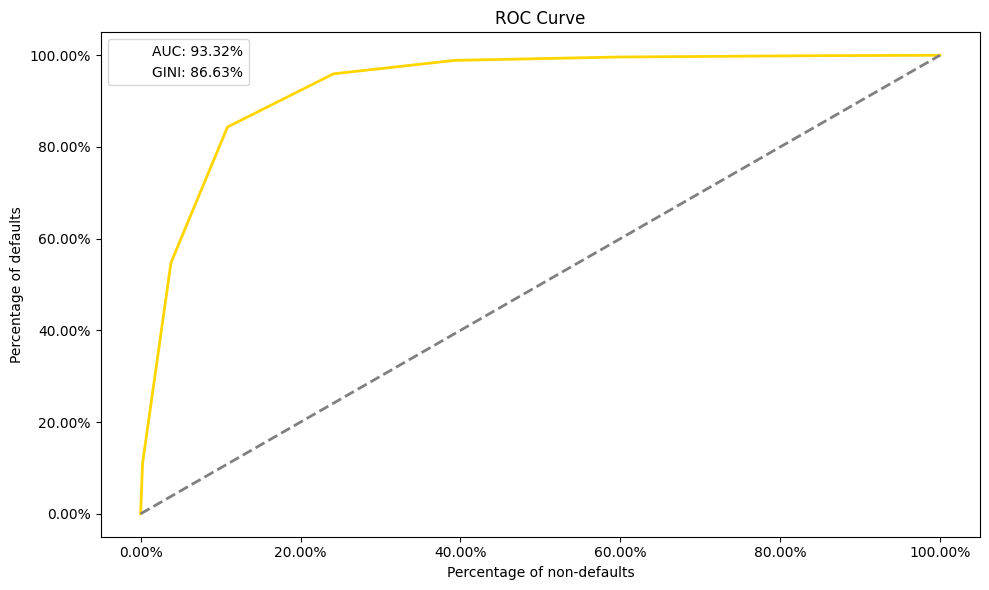

In [16]:
# Back-testing --> Classification ability (Portfolio level)
# Plot ROC
plot_roc(
    cum_good = score_table['cum_good'],
    cum_bad = score_table['cum_bad']
)

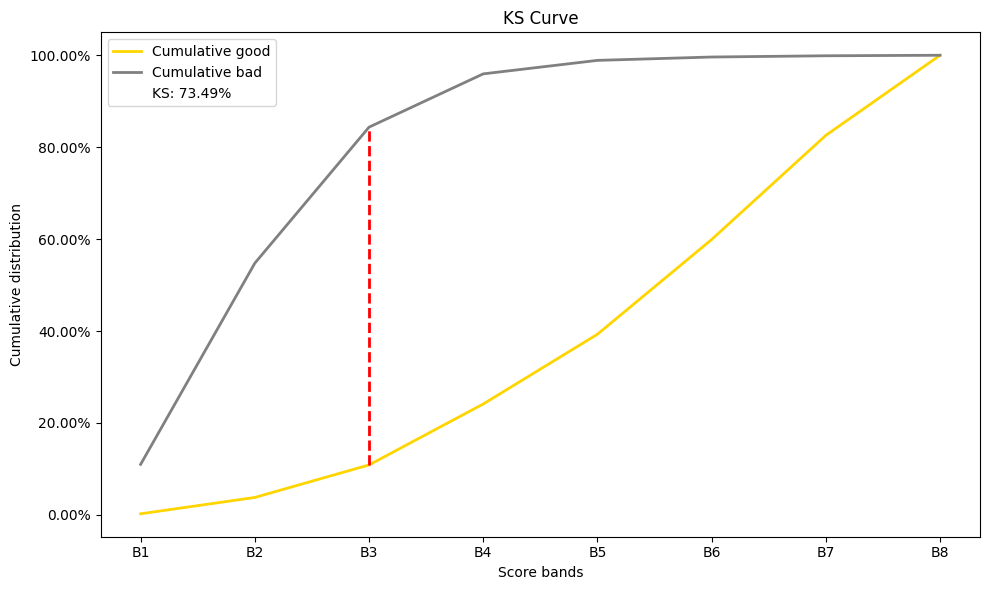

In [17]:
# Plot KS
plot_ks(
    cum_good = score_table['cum_good'],
    cum_bad = score_table['cum_bad']
)

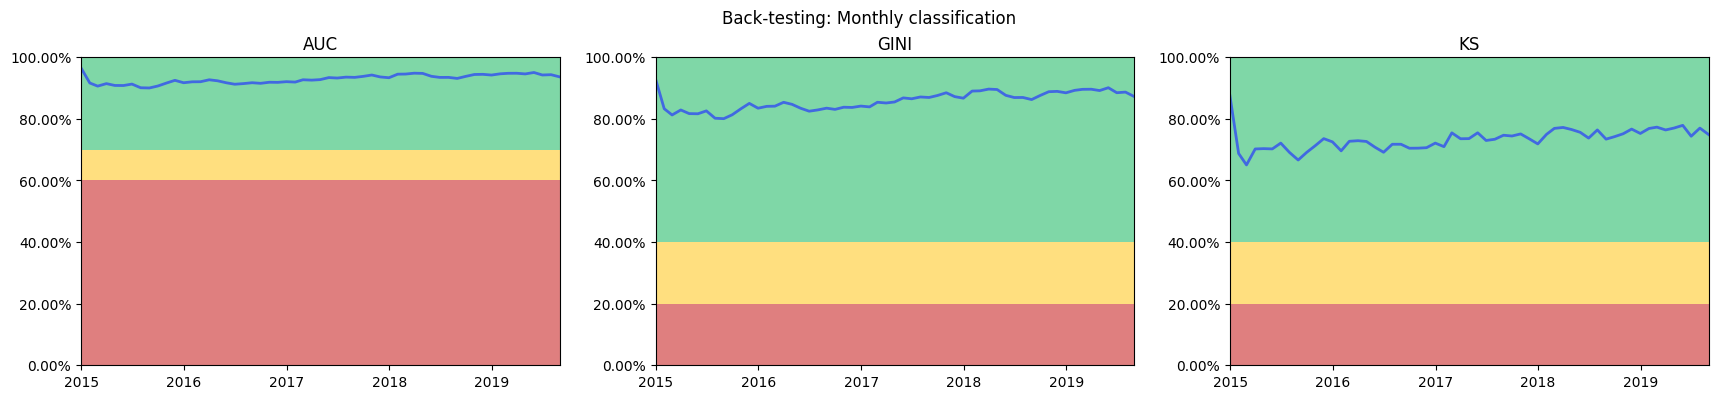

In [18]:
# Back-testing --> Classification ability (Monthly level)
plot_classification_monthly(
    month = month_idx,
    bin_labels = score_bands,
    y_true = y_all,
)


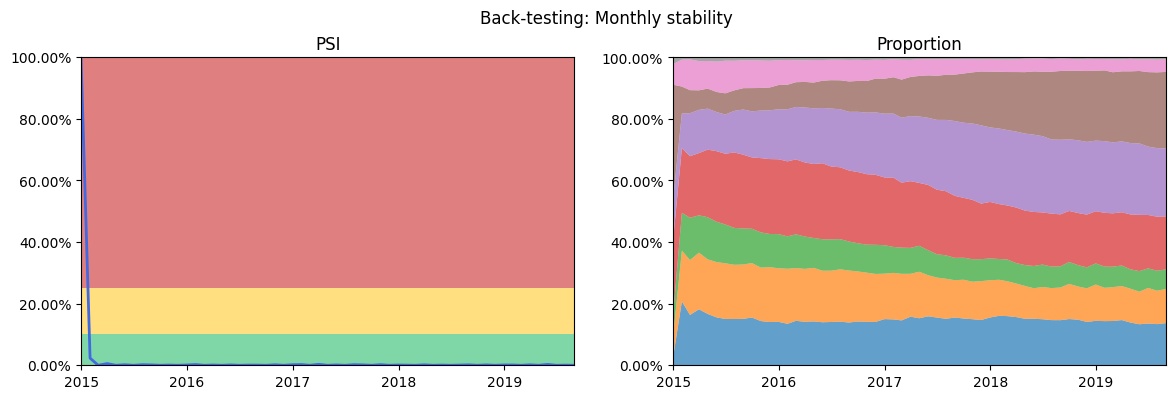

In [19]:
# Back-testing --> Stability (Monthly level)
por = plot_stability_monthly(
    month = month_idx,
    bin_labels = score_bands,
    y_true = y_all,
)

In [20]:
# Import dataset for another model (For use later)
df = pd.read_parquet(
    '../data/processed/behaviour_factors.parquet',
    engine = 'pyarrow'
)

# Extract only columns needed
use_cols = df.columns[: 31] #Defined by columns index
final_cols = list(use_cols) + model.feature_names_ #Final features from model

# Keep only columns needed
df = df[final_cols]

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,FIRST_PAYMENT_DATE,FIRST_TRANS_MONTH,MOB,del,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin
0,944370,A,N,1,507120.0,10,60.0,0,944370,6626063,...,2019-05-16,65.0,0.0,0,NaN,NaN,0.000000,NaN,NaN,NaN
1,944370,A,N,2,498668.0,10,60.0,0,944370,6626063,...,2019-05-16,65.0,1.0,0,0.083333,0.0,0.000000,0.0,0.0,0.021251
2,944370,A,N,2,490216.0,10,60.0,0,944370,6626063,...,2019-05-16,65.0,2.0,0,0.168079,0.0,0.111111,0.0,0.0,0.021251
3,944370,A,N,2,481764.0,10,60.0,0,944370,6626063,...,2019-05-16,65.0,3.0,0,0.254310,0.0,0.222222,0.0,0.0,0.021251
4,944370,A,N,2,473312.0,10,60.0,0,944370,6626063,...,2019-05-16,65.0,4.0,0,0.342105,0.0,0.333333,0.0,0.0,0.021251


In [21]:
# Extract for score assigning
df_features = df[model.feature_names_].dropna()
df_features[cat_cols] = df_features[cat_cols].replace([np.inf, -np.inf, np.nan], -1).astype(int)

# Compute score
scores_df = compute_feature_scores(
    base_model = model,
    X = df_features,
    pdo = PDO,
    base_score = BASE_SCORE,
    base_odds = BASE_ODDS
)

# Score bands process
score_bands_df = assign_score_bands(
    scores = scores_df['score_from_model'],
    n_bins = 8,
    method = 'equal'
)

=== Processing ===
[Score construction]
Total input: 766148


In [22]:
# Mapping to original data
df = df.join(
    [scores_df[['score_from_model']], score_bands_df.rename("score_band").to_frame()],
    how = "left"
)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,MOB,del,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin,score_from_model,score_band
0,944370,A,N,1,507120.0,10,60.0,0,944370,6626063,...,0.0,0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1,944370,A,N,2,498668.0,10,60.0,0,944370,6626063,...,1.0,0,0.083333,0.0,0.000000,0.0,0.0,0.021251,582.0,B3
2,944370,A,N,2,490216.0,10,60.0,0,944370,6626063,...,2.0,0,0.168079,0.0,0.111111,0.0,0.0,0.021251,582.0,B3
3,944370,A,N,2,481764.0,10,60.0,0,944370,6626063,...,3.0,0,0.254310,0.0,0.222222,0.0,0.0,0.021251,582.0,B3
4,944370,A,N,2,473312.0,10,60.0,0,944370,6626063,...,4.0,0,0.342105,0.0,0.333333,0.0,0.0,0.021251,515.0,B4


In [23]:
# Export
df.to_parquet(
    '../data/processed/usedcar_transaction_score.parquet',
    engine = 'pyarrow'
)